<a href="https://colab.research.google.com/github/lakshyacodes01/image-colorization/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Converting color image to Black and White**

In [104]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

In [59]:
img= tf.io.read_file('/content/Images/1000268201_693b08cb0e.jpg')

img= tf.image.decode_jpeg(img)
img=tf.cast(img,tf.float32)/255.0

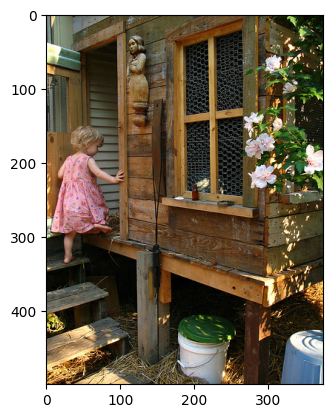

In [60]:
plt.imshow(img)

Formula to convert to grayscale from RGB

Gray= 0.299R + 0.587G + 0.114B

In [61]:
gray_img=tf.image.rgb_to_grayscale(img)

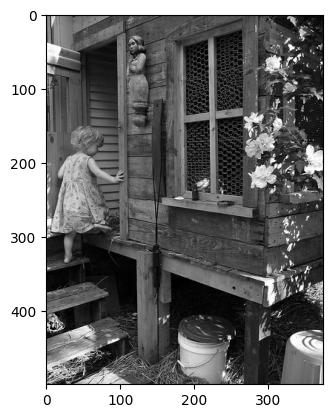

In [62]:
# To show converted image
plt.imshow(gray_img.numpy().squeeze(),cmap='gray')

Building the dataset pipeline

In [28]:
pip install tensorflow-io

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 108.0 MB/s eta 0:00:00


In [54]:
import tensorflow_io as tfio

In [42]:
# downloading dataset Flickr8k from kaggle
!mkdir -p ~/.kaggle
!mv kaggl.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggl.json

In [43]:
!kaggle datasets download -d adityajn105/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:11<00:00, 99.1MB/s]



In [44]:
!unzip flickr8k.zip

Streaming output truncated to the last 5000 lines.
  inflating: Images/2844846111_8c1cbfc75d.jpg  
  inflating: Images/2844963839_ff09cdb81f.jpg  
  inflating: Images/2845246160_d0d1bbd6f0.jpg  
  inflating: Images/2845691057_d4ab89d889.jpg  
  inflating: Images/2845845721_d0bc113ff7.jpg  
  inflating: Images/2846037553_1a1de50709.jpg  
  inflating: Images/2846785268_904c5fcf9f.jpg  
  inflating: Images/2846843520_b0e6211478.jpg  
  inflating: Images/2847514745_9a35493023.jpg  
  inflating: Images/2847615962_c330bded6e.jpg  
  inflating: Images/2847859796_4d9cb0d31f.jpg  
  inflating: Images/2848266893_9693c66275.jpg  
  inflating: Images/2848571082_26454cb981.jpg  
  inflating: Images/2848895544_6d06210e9d.jpg  
  inflating: Images/2848977044_446a31d86e.jpg  
  inflating: Images/2849194983_2968c72832.jpg  
  inflating: Images/2850719435_221f15e951.jpg  
  inflating: Images/2851198725_37b6027625.jpg  
  inflating: Images/2851304910_b5721199bc.jpg  
  inflating: Images/2851931813_eaf8ed

In [49]:
import glob

In [50]:
image_paths = glob.glob("/content/Images/*.jpg")

In [51]:
print(len(image_paths))

8091


In [52]:
print(image_paths[:5])

['/content/Images/1131155939_b4b457b05e.jpg', '/content/Images/1813777902_07d1d4b00c.jpg', '/content/Images/3328646934_5cca4cebce.jpg', '/content/Images/2642350864_099c0f2152.jpg', '/content/Images/190638179_be9da86589.jpg']


In [55]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [70]:
# Load and preprocess image
def load_image(path):
  # read file
  img=tf.io.read_file(path)
  # decode jped -> (H,W,3)
  img= tf.image.decode_jpeg(img,channels=3)
  # resize to fix size
  img=tf.image.resize(img,(IMG_SIZE,IMG_SIZE))
  # Normalize
  img=tf.cast(img,tf.float32)/255.0
  # Convert RGB -> LAB
  lab=tfio.experimental.color.rgb_to_lab(img)
  # Split channels
  L=lab[:,:,0:1]
  ab=lab[:,:,1:]
  # Normalize LAB range
  L=L/100.0
  ab=ab/128.0
  return L,ab

In [82]:
# Create Dataset
def create_dataset(image_paths):
  dataset=tf.data.Dataset.from_tensor_slices(image_paths)
  dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
  # apply preprocessing
  dataset=dataset.shuffle(buffer_size=1000)
  # batch
  dataset=dataset.batch(BATCH_SIZE)

  # optimize pipeline
  dataset=dataset.prefetch(tf.data.AUTOTUNE)
  return dataset

In [83]:
import random

In [84]:
image_paths=glob.glob("/content/Images/*.jpg")
# reduce size for faster training
images_paths=random.sample(image_paths,3000)
# create dataset
train_dataset=create_dataset(images_paths)


In [85]:
for item in train_dataset.take(1):
  print(type(item))
  print(len(item))

<class 'tuple'>
2


Checking if dataset is correct

In [89]:
for L, ab in train_dataset.take(1):
    L_sample = L[0]
    ab_sample = ab[0]

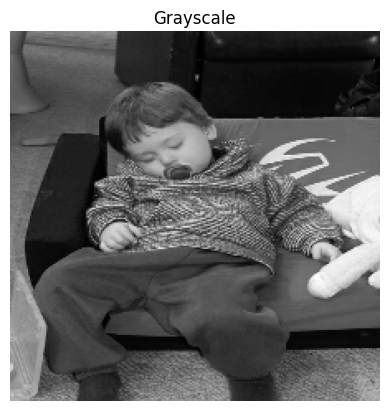

In [90]:
import matplotlib.pyplot as plt

plt.imshow(L_sample.numpy().squeeze(), cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()

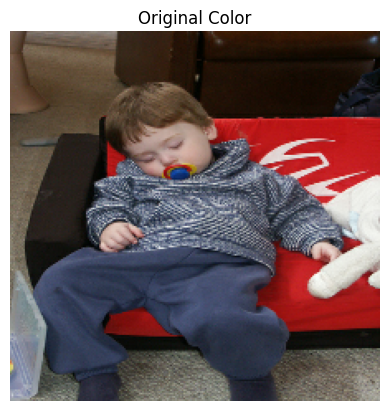

In [91]:
import numpy as np
import cv2

L = L_sample.numpy() * 100
ab = ab_sample.numpy() * 128

lab = np.concatenate([L, ab], axis=-1).astype(np.float32)
rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

plt.imshow(rgb)
plt.title("Original Color")
plt.axis('off')
plt.show()

**BUILDING THE MODEL**

In [92]:
from tensorflow.keras import Sequential,layers,Model


In [132]:
# Loading ResNet50 model
base_model=tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE,IMG_SIZE,3)
)

In [133]:
for layer in base_model.layers:
  layer.trainable=False

In [134]:
inputs=tf.keras.Input(shape=(224,224,1))

In [135]:
x=layers.Concatenate()([inputs,inputs,inputs])

In [136]:
x=base_model(x)

In [137]:
x=layers.Conv2DTranspose(256,3,strides=2,padding='same',activation='relu')(x)
x=layers.Conv2DTranspose(128,3,strides=2,padding='same',activation='relu')(x)
x=layers.Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(x)
x=layers.Conv2DTranspose(32,3,strides=2,padding='same',activation='relu')(x)
x=layers.Conv2DTranspose(16,3,strides=2,padding='same',activation='relu')(x)

outputs=layers.Conv2D(2,3,padding='same',activation='tanh')(x)




In [138]:
model=Model(inputs,outputs)

In [139]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_4[0]… │
│                     │                   │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ concatenate_1[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_14 │ (None, 14, 14,    │  4,718,848 │ resnet50[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_15 │ (None, 28, 28,    │    295,040 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_16 │ (None, 56, 56,    │     73,792 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_17 │ (None, 112, 112,  │     18,464 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_18 │ (None, 224, 224,  │      4,624 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │        290 │ conv2d_transpose… │
│                     │ 2)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,698,770 (109.48 MB)

 Trainable params: 5,111,058 (19.50 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [140]:
from sklearn.model_selection import train_test_split

In [141]:
train_paths,val_paths=train_test_split(image_paths,test_size=0.2,random_state=42 )

In [142]:
train_dataset = create_dataset(train_paths)
val_dataset = create_dataset(val_paths)

In [143]:
model.compile(optimizer='adam',loss='mse',metrics=['accuracy'])

In [145]:
history=model.fit(train_dataset,validation_data=val_dataset,epochs=10)

Epoch 1/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 136s 609ms/step - accuracy: 0.6668 - loss: 0.0140 - val_accuracy: 0.6677 - val_loss: 0.0139
Epoch 2/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 115s 502ms/step - accuracy: 0.6668 - loss: 0.0139 - val_accuracy: 0.6677 - val_loss: 0.0138
Epoch 3/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 116s 507ms/step - accuracy: 0.6668 - loss: 0.0138 - val_accuracy: 0.6677 - val_loss: 0.0137
Epoch 4/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 113s 491ms/step - accuracy: 0.6668 - loss: 0.0137 - val_accuracy: 0.6677 - val_loss: 0.0136
Epoch 5/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 160s 579ms/step - accuracy: 0.6665 - loss: 0.0137 - val_accuracy: 0.6677 - val_loss: 0.0136
Epoch 6/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 113s 493ms/step - accuracy: 0.6678 - loss: 0.0136 - val_accuracy: 0.6703 - val_loss: 0.0136
Epoch 7/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 142s 494ms/step - accuracy: 0.6678 - loss: 0.0136 - val_accuracy: 0.6705 - val_loss: 0.0135
Epoch 8/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 142s 495ms/step - accuracy: 0.6684 -

In [155]:
import tensorflow as tf
import tensorflow_io as tfio
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG_SIZE = 224

# load image
img = tf.io.read_file('/content/trial2.jpg')
img = tf.image.decode_jpeg(img, channels=3)
img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
img = tf.cast(img, tf.float32) / 255.0

# convert to LAB
lab = tfio.experimental.color.rgb_to_lab(img)

L = lab[:, :, 0:1]
ab = lab[:, :, 1:]

# normalize
L_input = L / 100.0

In [156]:
L_input = tf.expand_dims(L_input, axis=0)  # add batch

pred_ab = model.predict(L_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


In [157]:
# remove batch
pred_ab = pred_ab[0]

# denormalize
L = L.numpy()
pred_ab = pred_ab * 128

# combine
lab = np.concatenate([L, pred_ab], axis=-1).astype(np.float32)

# LAB → RGB
rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

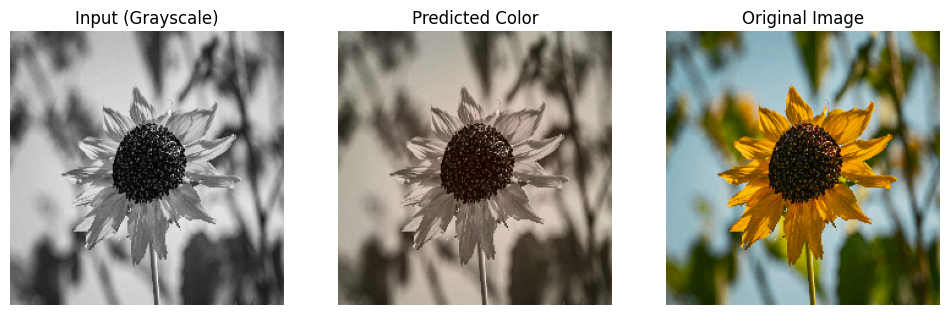

In [158]:
plt.figure(figsize=(12,4))

# grayscale input
plt.subplot(1,3,1)
plt.imshow(L.squeeze(), cmap='gray')
plt.title("Input (Grayscale)")
plt.axis('off')

# predicted color
plt.subplot(1,3,2)
plt.imshow(rgb)
plt.title("Predicted Color")
plt.axis('off')

# original (for comparison)
plt.subplot(1,3,3)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.show()